In [1]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout



In [2]:
import pandas as pd

# Load the dataset
file_path = '../../data/Data3.csv'  # Update with your actual file path
data = pd.read_csv(file_path)

# Create a 'Site' column with the first 7 letters of the 'ERBS' column
data['Site'] = data['ERBS'].str[:7]

# Convert STARTTIME_DATE to datetime if it is not already
data['STARTTIME_DATE'] = pd.to_datetime(data['STARTTIME_DATE'])

# Group by 'Site' and 'STARTTIME_DATE', then average the values
grouped_data = data.groupby(['Site', 'STARTTIME_DATE']).mean().reset_index()

C:\Users\HP\AppData\Local\Temp\ipykernel_4828\3386111187.py:14: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  grouped_data = data.groupby(['Site', 'STARTTIME_DATE']).mean().reset_index()


In [5]:
data.columns


Index(['STARTTIME_DATE', 'ERBS', 'Site', 'EUTRANCELLFDD', 'AVG_NO_USER',
       'AVG_USR_THRPUT_DL', 'AVG_USR_THRPUT_UL', 'CSSR',
       'DL_256QAM_PROPORTION', 'DL_LATENCY', 'DL_PACK_LOSS_RATE',
       'DL_QPSK_PROPORTION', 'DL_TRAFFIC_MB', 'MAX_NO_USER', 'S1_SIG_SUCC',
       'TOTAL_DOWNTIME', 'TOTAL_TRAFFIC', 'UL_QPSK_PROPORTION',
       'UL_TRAFFIC_MB'],
      dtype='object')

In [7]:
data

,STARTTIME_DATE,ERBS,Site,EUTRANCELLFDD,AVG_NO_USER,AVG_USR_THRPUT_DL,AVG_USR_THRPUT_UL,CSSR,DL_256QAM_PROPORTION,DL_LATENCY,DL_PACK_LOSS_RATE,DL_QPSK_PROPORTION,DL_TRAFFIC_MB,MAX_NO_USER,S1_SIG_SUCC,TOTAL_DOWNTIME,TOTAL_TRAFFIC,UL_QPSK_PROPORTION,UL_TRAFFIC_MB
0,2022-09-01,CXUKH48_01,CXUKH48,CXUKH48LA,92.77,5.18,1.87,99.57,2.82,6.64,0.05,24.77,266338.94,165,299748,0,294973.99,11.92,28635.04
1,2022-09-01,CXUKH62_02,CXUKH62,CXUKH62LC,245.27,0.34,0.69,99.86,0.11,16.41,0.12,26.74,330611.64,422,667985,0,413566.26,14.96,82954.61
2,2022-09-01,CXUKH28L,CXUKH28,CXUKH28LF,24.04,11.24,0.81,99.50,1.23,5.63,0.06,39.69,95901.41,67,70619,70,104506.25,25.32,8604.82
3,2022-09-01,CXUKH30_01,CXUKH30,CXUKH30LA,66.43,2.99,0.63,99.80,4.22,4.96,0.07,23.00,216824.44,125,255885,88,237991.37,25.66,21166.95
4,2022-09-01,CXUKH39L,CXUKH39,CXUKH39LB,384.43,0.17,0.31,99.73,0.16,37.29,0.13,30.13,282525.31,616,1249400,0,371425.21,23.64,88899.92
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
360298,2023-09-01,BMKSB35,BMKSB35,BMKSB35LA,86.52,3.74,0.61,99.89,0.43,4.83,0.04,30.46,241224.31,152,228362,0,274555.92,52.58,33331.61
360299,2023-09-01,BMKSB28B02,BMKSB28,BMKSB28L21B,16.13,6.05,0.40,99.59,1.24,3.05,0.11,27.94,40245.81,83,57939,511,45180.19,63.86,4934.37
360300,2023-09-01,BMKSB28B02,BMKSB28,BMKSB28L21C,18.65,5.79,0.37,99.63,0.37,2.90,0.08,27.35,58491.32,54,41986,0,65613.49,74.31,7122.17
360301,2023-09-01,BMKSB20L,BMKSB20,BMKSB20L21A,8.25,6.33,0.52,99.83,1.13,2.54,0.05,43.98,25353.27,31,24518,0,28457.14,59.42,3103.87


<Axes: >

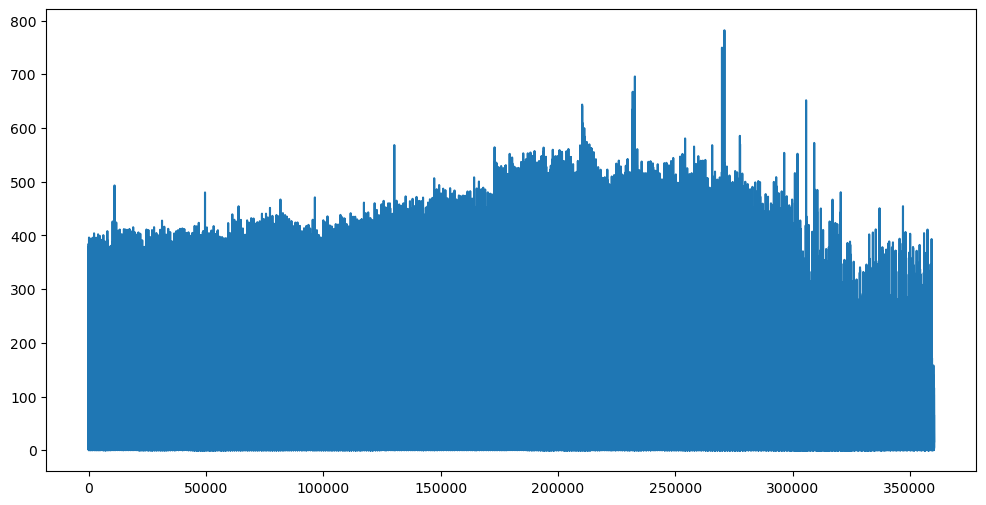

In [8]:
data['AVG_NO_USER'].plot(figsize=(12, 6))

In [9]:
data.to_excel('Sitewise KPI.xlsx', index=False)


In [10]:
data['Site'] = data['Site'].str.replace('CXUKH', 'SiteA')
data['Site'] = data['Site'].str.replace('BMKSB', 'SiteB')

In [11]:
data['Site'] = data['Site'].str.replace('CGANW', 'SiteC')
data['Site'] = data['Site'].str.replace('BMBNC', 'SiteD')

In [12]:
def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data[i:i+seq_length]
        y = data[i+seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

In [8]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [9]:
# Load the dataset and prepare the data
file_path = '../../data/Data3.csv'  # Update with your actual file path
data = pd.read_csv(file_path)
data['Site'] = data['ERBS'].str[:7]
data['STARTTIME_DATE'] = pd.to_datetime(data['STARTTIME_DATE'])
grouped_data = data.groupby(['Site', 'STARTTIME_DATE']).mean().reset_index()

C:\Users\HP\AppData\Local\Temp\ipykernel_128648\2273355793.py:6: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  grouped_data = data.groupby(['Site', 'STARTTIME_DATE']).mean().reset_index()


In [13]:
# Define the create_sequences function
def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data[i:i+seq_length]
        y = data[i+seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

# Function to calculate MSE for each site
def calculate_mse_for_sites(target_column):
    mse_results = {}
    for site in grouped_data['Site'].unique():
        site_data = grouped_data[grouped_data['Site'] == site][target_column].values
        site_data = site_data.reshape(-1, 1)
        
        if len(site_data) <= 10:
            continue
        
        X, y = create_sequences(site_data, seq_length=10)
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        
        # Define and train the LSTM model
        model = Sequential()
        model.add(LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
        model.add(Dropout(0.2))
        model.add(LSTM(50, return_sequences=False))
        model.add(Dropout(0.2))
        model.add(Dense(1))
        
        model.compile(optimizer='adam', loss='mean_squared_error')
        model.fit(X_train, y_train, epochs=10, batch_size=16, validation_split=0.2, verbose=0)
        
        # Predict and calculate MSE
        y_pred = model.predict(X_test)
        mse = mean_squared_error(y_test, y_pred)
        
        mse_results[site] = mse
    
    return mse_results

# Calculate MSE for AVG_NO_USER
mse_results_no_user = calculate_mse_for_sites('AVG_NO_USER')

3/3 [==============================] - 2s 8ms/step


3/3 [==============================] - 2s 8ms/step


In [11]:
# Sort results and get the best and worst 5 sites
sorted_mse_results = sorted(mse_results_no_user.items(), key=lambda x: x[1])
best_5_sites = sorted_mse_results[:5]
worst_5_sites = sorted_mse_results[-5:]

print("Best 5 Sites based on MSE:", best_5_sites)
print("Worst 5 Sites based on MSE:", worst_5_sites)

Best 5 Sites based on MSE: [('CXUKH23', 5.028087123706406), ('CGANW20', 7.999638331655809), ('BMBNC49', 11.831586900722101), ('BMBNC55', 16.133773899072192), ('BMKSB22', 27.361953564564075)]
Worst 5 Sites based on MSE: [('CXUKH38', 15505.902489034193), ('CXUKH63', 26417.475282983225), ('CXUKH39', 47636.68670948365), ('CXUKH62', 50029.22727960565), ('CXUKH64', 63817.22348311162)]


In [13]:
import matplotlib.pyplot as plt

In [14]:
# Plot actual vs predicted values for the best and worst 5 sites
def plot_actual_vs_predicted(site, y_test, y_pred):
    plt.figure(figsize=(10, 5))
    plt.plot(y_test, label='Actual')
    plt.plot(y_pred, label='Predicted')
    plt.title(f'Actual vs Predicted for AVG_NO_USER - Site: {site}')
    plt.xlabel('Time Steps')
    plt.ylabel('AVG_NO_USER')
    plt.legend()
    plt.show()

# Plot for the best 5 sites
for site, _ in best_5_sites:
    if site in site_predictions_no_user:
        y_test, y_pred = site_predictions_no_user[site]
        plot_actual_vs_predicted(site, y_test, y_pred)
    else:
        print(f"Site {site} not found in site_predictions_no_user.")

# Plot for the worst 5 sites
for site, _ in worst_5_sites:
    if site in site_predictions_no_user:
        y_test, y_pred = site_predictions_no_user[site]
        plot_actual_vs_predicted(site, y_test, y_pred)
    else:
        print(f"Site {site} not found in site_predictions_no_user.")

Site CXUKH23 not found in site_predictions_no_user.
Site CGANW20 not found in site_predictions_no_user.
Site BMBNC49 not found in site_predictions_no_user.
Site BMBNC55 not found in site_predictions_no_user.
Site BMKSB22 not found in site_predictions_no_user.
Site CXUKH38 not found in site_predictions_no_user.
Site CXUKH63 not found in site_predictions_no_user.
Site CXUKH39 not found in site_predictions_no_user.
Site CXUKH62 not found in site_predictions_no_user.
Site CXUKH64 not found in site_predictions_no_user.


C:\Users\HP\AppData\Local\Temp\ipykernel_128648\761049028.py:14: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  grouped_data = data.groupby(['Site', 'STARTTIME_DATE']).mean().reset_index()


1/1 [==============================] - 2s 2s/step
Skipping site BMBNC54 due to insufficient data.
3/3 [==============================] - 2s 8ms/step


3/3 [==============================] - 2s 3ms/step
Best 5 Sites based on MSE: [('CXUKH23', 5.027343925845121), ('CGANW20', 7.019298678159459), ('BMBNC49', 13.361268478204867), ('BMBNC55', 13.978259761638359), ('BMKSB22', 32.76819654406571)]
Worst 5 Sites based on MSE: [('CXUKH38', 15666.778145403796), ('CXUKH63', 26937.030725514705), ('CXUKH39', 47649.27826846127), ('CXUKH62', 50450.56957043198), ('CXUKH64', 63415.15809755129)]


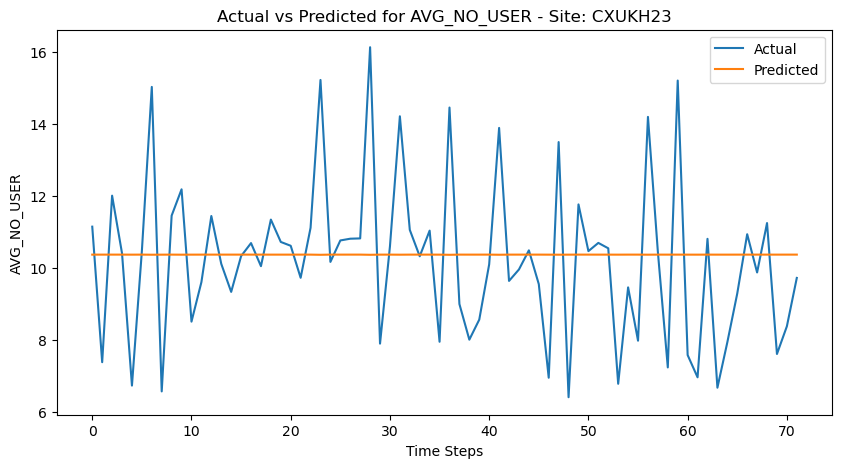

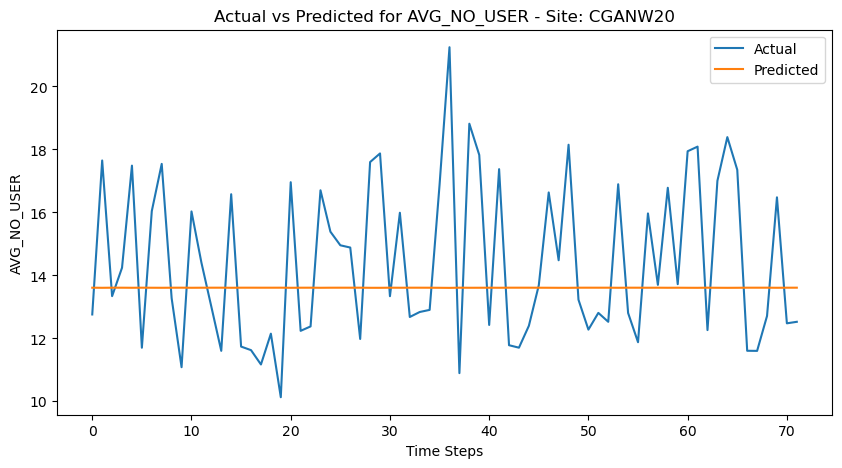

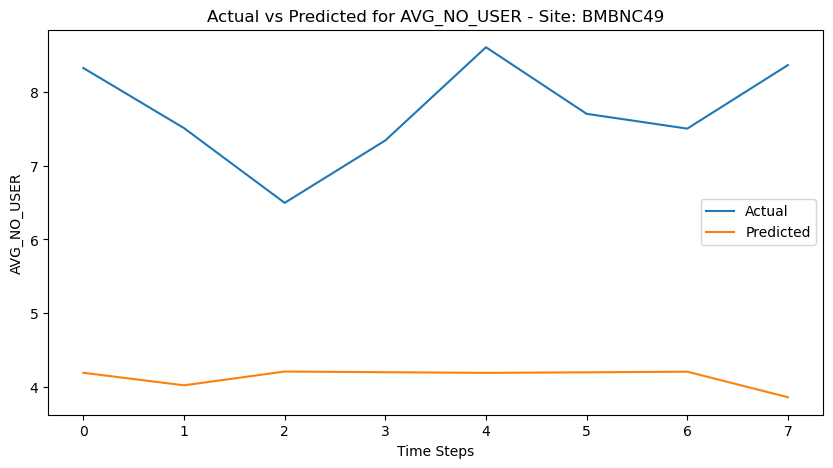

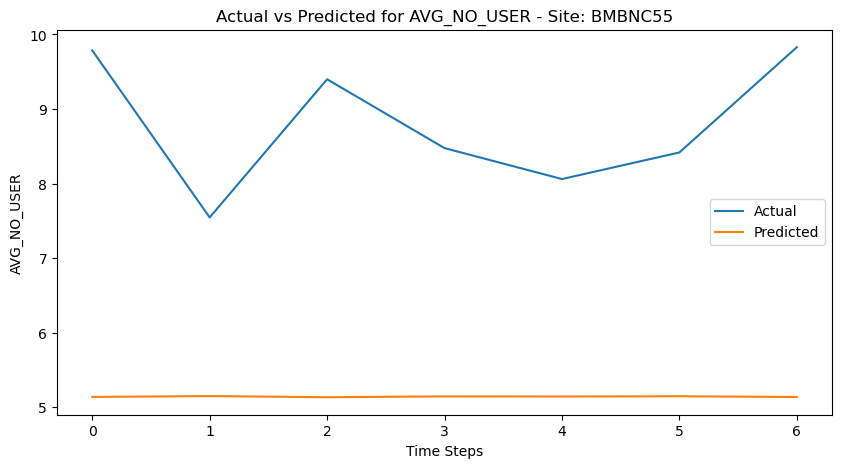

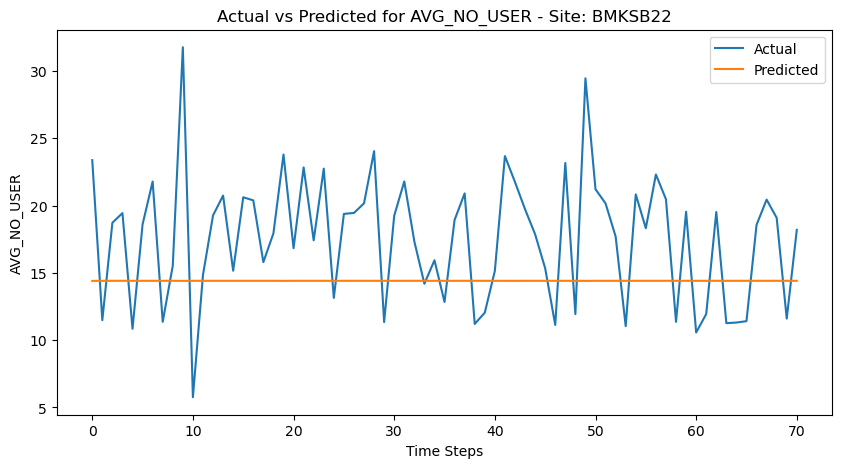

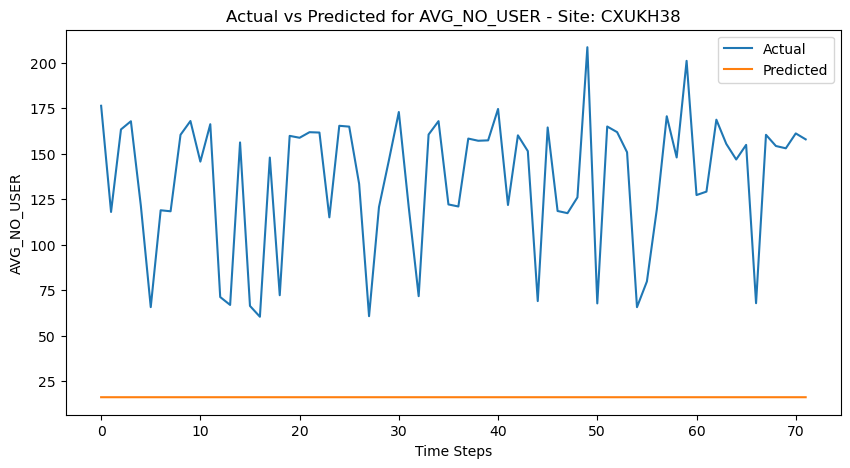

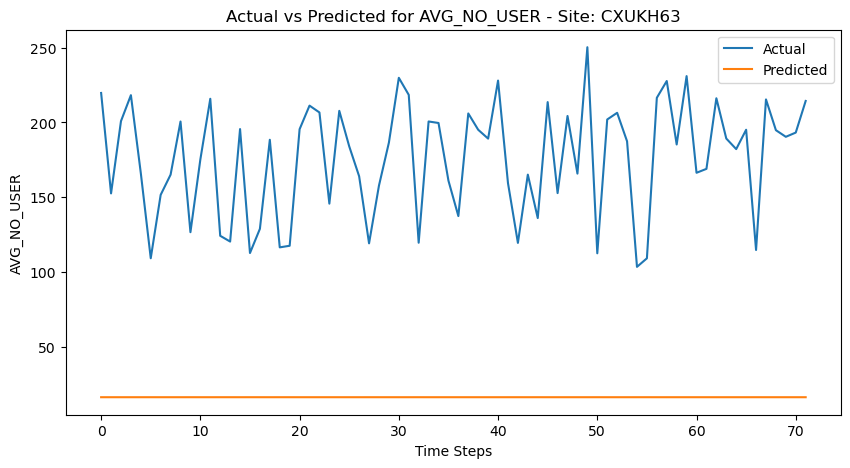

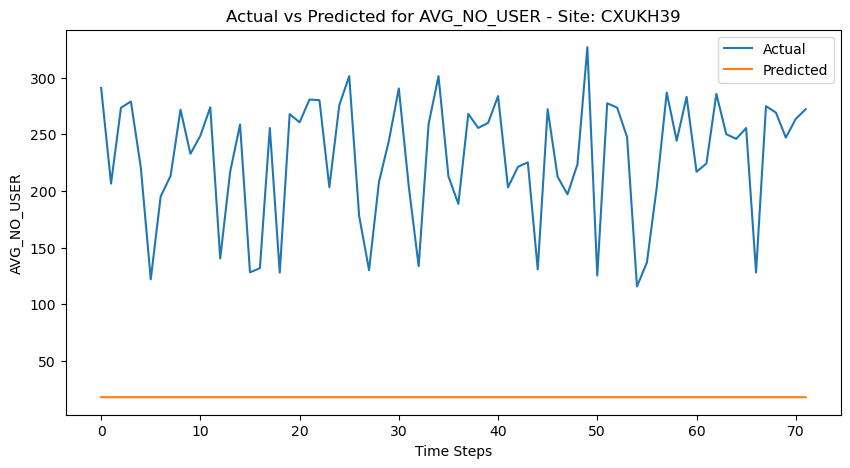

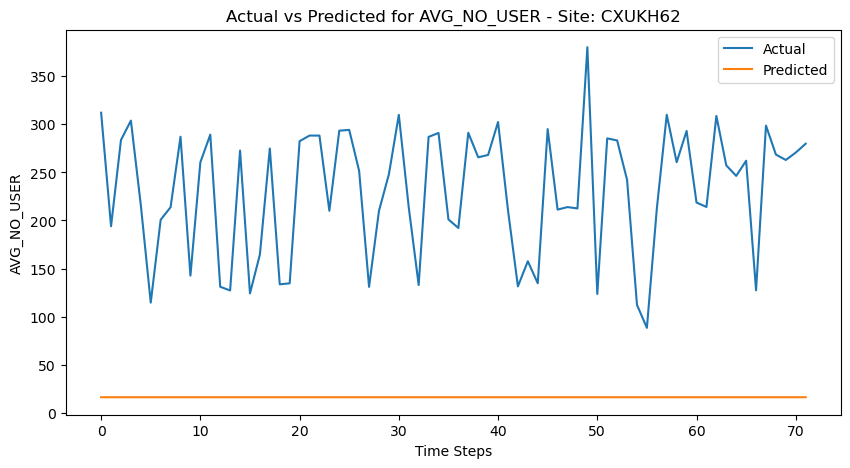

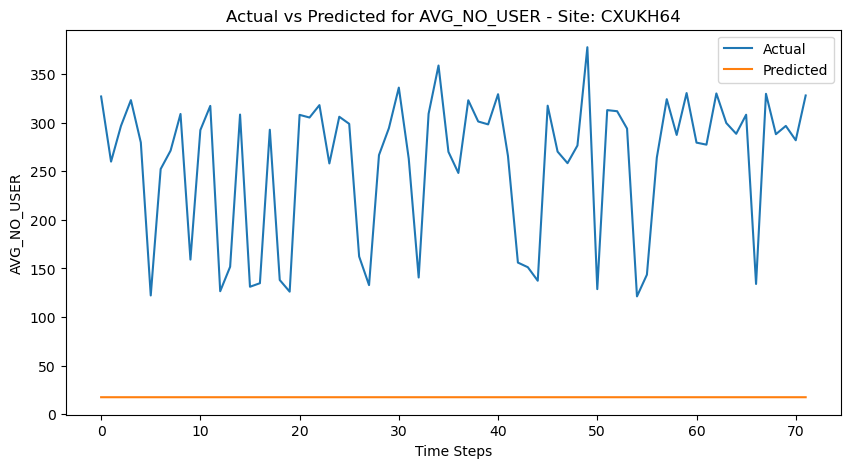

In [15]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import matplotlib.pyplot as plt

# Load the dataset and prepare the data
file_path = '../../data/Data3.csv'  # Update with your actual file path
data = pd.read_csv(file_path)
data['Site'] = data['ERBS'].str[:7]
data['STARTTIME_DATE'] = pd.to_datetime(data['STARTTIME_DATE'])
grouped_data = data.groupby(['Site', 'STARTTIME_DATE']).mean().reset_index()

# Define the create_sequences function
def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data[i:i+seq_length]
        y = data[i+seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

# Function to calculate MSE for each site
def calculate_mse_for_sites(target_column):
    mse_results = {}
    site_predictions = {}
    for site in grouped_data['Site'].unique():
        site_data = grouped_data[grouped_data['Site'] == site][target_column].values
        site_data = site_data.reshape(-1, 1)
        
        if len(site_data) <= 10:
            print(f"Skipping site {site} due to insufficient data.")
            continue
        
        X, y = create_sequences(site_data, seq_length=10)
        if len(X) == 0:
            print(f"Skipping site {site} because the sequence length is too long for the data.")
            continue

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        
        # Define and train the LSTM model
        model = Sequential()
        model.add(LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
        model.add(Dropout(0.2))
        model.add(LSTM(50, return_sequences=False))
        model.add(Dropout(0.2))
        model.add(Dense(1))
        
        model.compile(optimizer='adam', loss='mean_squared_error')
        model.fit(X_train, y_train, epochs=10, batch_size=16, validation_split=0.2, verbose=0)
        
        # Predict and calculate MSE
        y_pred = model.predict(X_test)
        mse = mean_squared_error(y_test, y_pred)
        
        mse_results[site] = mse
        site_predictions[site] = (y_test, y_pred)
    
    return mse_results, site_predictions

# Calculate MSE and get predictions for AVG_NO_USER
mse_results_no_user, site_predictions_no_user = calculate_mse_for_sites('AVG_NO_USER')

# Sort results and get the best and worst 5 sites
sorted_mse_results = sorted(mse_results_no_user.items(), key=lambda x: x[1])
best_5_sites = sorted_mse_results[:5]
worst_5_sites = sorted_mse_results[-5:]

print("Best 5 Sites based on MSE:", best_5_sites)
print("Worst 5 Sites based on MSE:", worst_5_sites)

# Plot actual vs predicted values for the best and worst 5 sites
def plot_actual_vs_predicted(site, y_test, y_pred):
    plt.figure(figsize=(10, 5))
    plt.plot(y_test, label='Actual')
    plt.plot(y_pred, label='Predicted')
    plt.title(f'Actual vs Predicted for AVG_NO_USER - Site: {site}')
    plt.xlabel('Time Steps')
    plt.ylabel('AVG_NO_USER')
    plt.legend()
    plt.show()

# Plot for the best 5 sites
for site, _ in best_5_sites:
    if site in site_predictions_no_user:
        y_test, y_pred = site_predictions_no_user[site]
        plot_actual_vs_predicted(site, y_test, y_pred)
    else:
        print(f"Site {site} not found in site_predictions_no_user.")

# Plot for the worst 5 sites
for site, _ in worst_5_sites:
    if site in site_predictions_no_user:
        y_test, y_pred = site_predictions_no_user[site]
        plot_actual_vs_predicted(site, y_test, y_pred)
    else:
        print(f"Site {site} not found in site_predictions_no_user.")

3/3 [==============================] - 1s 8ms/step


3/3 [==============================] - 2s 8ms/step


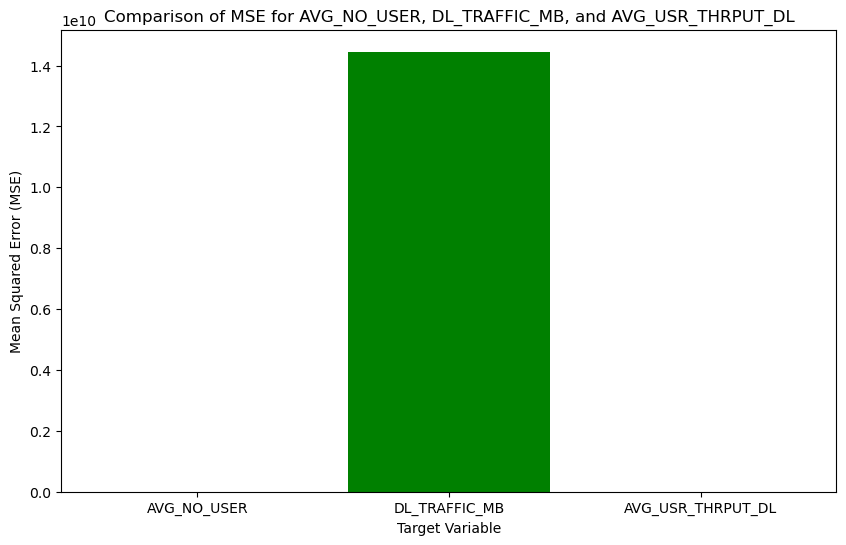

In [16]:

# Define the create_sequences function
def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data[i:i+seq_length]
        y = data[i+seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

# Function to calculate MSE for each target variable
def calculate_mse_for_sites(target_column):
    mse_results = []
    for site in grouped_data['Site'].unique():
        site_data = grouped_data[grouped_data['Site'] == site][target_column].values
        site_data = site_data.reshape(-1, 1)
        
        if len(site_data) <= 10:
            continue
        
        X, y = create_sequences(site_data, seq_length=10)
        if len(X) == 0:
            continue

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        
        # Define and train the LSTM model
        model = Sequential()
        model.add(LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
        model.add(Dropout(0.2))
        model.add(LSTM(50, return_sequences=False))
        model.add(Dropout(0.2))
        model.add(Dense(1))
        
        model.compile(optimizer='adam', loss='mean_squared_error')
        model.fit(X_train, y_train, epochs=10, batch_size=16, validation_split=0.2, verbose=0)
        
        # Predict and calculate MSE
        y_pred = model.predict(X_test)
        mse = mean_squared_error(y_test, y_pred)
        
        mse_results.append(mse)
    
    return np.mean(mse_results)

# Calculate MSE for each target variable
mse_avg_no_user = calculate_mse_for_sites('AVG_NO_USER')
mse_dl_traffic_mb = calculate_mse_for_sites('DL_TRAFFIC_MB')
mse_avg_usr_thrput_dl = calculate_mse_for_sites('AVG_USR_THRPUT_DL')

# Aggregate the results
mse_comparison = {
    'AVG_NO_USER': mse_avg_no_user,
    'DL_TRAFFIC_MB': mse_dl_traffic_mb,
    'AVG_USR_THRPUT_DL': mse_avg_usr_thrput_dl
}

# Visualize the results
plt.figure(figsize=(10, 6))
plt.bar(mse_comparison.keys(), mse_comparison.values(), color=['blue', 'green', 'red'])
plt.title('Comparison of MSE for AVG_NO_USER, DL_TRAFFIC_MB, and AVG_USR_THRPUT_DL')
plt.xlabel('Target Variable')
plt.ylabel('Mean Squared Error (MSE)')
plt.show()